In [1]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
import fig_helper as fh
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter


gs.set_graph_style(1.0)


Scaling factor: 1.062 ± 0.006


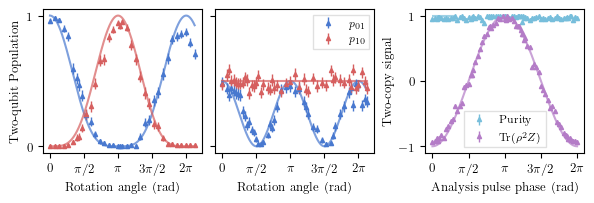

In [ ]:
def load_bmat_data(rid, date, get_par=True):
    f = fh.load_data(rid, date)
    # for x in f["datasets"].keys():
    #     print(x)

    p00 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_00"])
    p01 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_01"])
    p10 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_10"])
    p11 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_11"])
    p_err_00 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_00"])
    p_err_01 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_01"])
    p_err_10 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_10"])
    p_err_11 = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_p_err_11"])
    x = np.array(f["datasets"][f"ndscan.rid_{rid}.points.axis_0"])

    if get_par:
        purity = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_purity"])
        tr_rho2Z = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_tr_rho2Z"])
        purity_err = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_purity_err"])
        tr_rho2Z_err = np.array(f["datasets"][f"ndscan.rid_{rid}.points.channel_readout_tr_rho2Z_err"])
    else:
        purity = []
        tr_rho2Z = []
        purity_err = []
        tr_rho2Z_err = []


    return x, p01, p10, p_err_01, p_err_10, purity, tr_rho2Z, purity_err, tr_rho2Z_err

def pop_arr_F(p0110_arr, p_err_0110_arr):
    pop_err = np.mean(p0110_arr)
    pop_err_std = np.std(p0110_arr) / np.sqrt(len(p0110_arr))
    return pop_err, pop_err_std

def sinusoid_func(x, a, b, c, d):
    a = 1
    d = 0
    return a * np.sin(b * x + c) + d

def B_mat_pops(x_arr,s, init_state="01"):
    a = 1/np.sqrt(2)
    b = 1j/np.sqrt(2)
    B = np.matrix([[-1, 0, 0, 0],
                [0, a, a, 0],
                [0, -b, b, 0],
                [0, 0, 0, -1j]])

    p01_arr = np.array([])
    p10_arr = np.array([])
    for x in x_arr:
        t = x*s
        if init_state == "01":
            c = -1j*np.cos(t/2)*np.sin(t/2)
            d = np.cos(t/2)**2
            e = -np.sin(t/2)**2
            psi = np.array([c, d, e, c])
        elif init_state == "00":
            psi = np.array([1, 0, 0, 0])
        rho = np.outer(psi, np.conjugate(psi))
        rho_out = B @ rho @ np.conjugate(B.T)
        p01 = np.real(rho_out[1, 1])
        p10 = np.real(rho_out[2, 2])
        p01_arr = np.append(p01_arr, p01)
        p10_arr = np.append(p10_arr, p10)
    return p01_arr, p10_arr

def global_rot(x_arr, s):
    p01_arr = np.array([])
    p10_arr = np.array([])
    for x in x_arr:
        t = x*s
        c = -1j*np.cos(t/2)*np.sin(t/2)
        d = np.cos(t/2)**2
        e = -np.sin(t/2)**2
        psi = np.array([c, d, e, c])
        rho = np.outer(psi, np.conjugate(psi))
        p01 = np.real(rho[1, 1])
        p10 = np.real(rho[2, 2])
        p01_arr = np.append(p01_arr, p01)
        p10_arr = np.append(p10_arr, p10)
    return p01_arr, p10_arr

# def global_rot_model(x, s):
#     t = x*s
#     c = -1j*np.cos(t/2)*np.sin(t/2)
#     d = np.cos(t/2)**2
#     e = -np.sin(t/2)**2
#     psi = np.array([c, d, e, c])
#     rho = np.outer(psi, np.conjugate(psi))
#     p01 = np.real(rho[1, 1])
#     p10 = np.real(rho[2, 2])
#     print(f"p01: {p01}, p10: {p10}")
#     return np.concatenate([p01, p10])
def global_rot_model(x, s):
    t = x * s

    p01 = np.cos(t/2)**4
    p10 = np.sin(t/2)**4

    return np.concatenate([p01, p10])

date = "2026-04-16"
rid = 101494
x01, z_01, z_10, z_err_01, z_err_10, _, _, _, _ = load_bmat_data(rid, date, get_par=False)
x01 = x01*np.pi
date = "2026-04-16" 
rid = 101496
x01B, z_01B, z_10B, z_err_01B, z_err_10B, _, _, _, _ = load_bmat_data(rid, date, get_par=False)
x01B = x01B*np.pi
date = "2026-06-11"
rid = 130219
xpur, _, _, _, _, purity, tr_rho2Z, purity_err, tr_rho2Z_err = load_bmat_data(rid, date, get_par=True)
z_corr = tr_rho2Z / purity
# Ramsey
date = "2026-06-02"
rid = 128499
xram, _, _, _, _, purityram, tr_rho2Zram, purity_errram, tr_rho2Z_errram = load_bmat_data(rid, date, get_par=True)
xram = xram*2*np.pi

popt, pcov = curve_fit(global_rot_model, x01, np.concatenate([z_01, z_10])) # use non-B data to correct for x scaling
s = popt[0] # this gives a scaling factor for the rotation angle
print(f"Scaling factor: {s:.3f} ± {np.sqrt(np.diag(pcov))[0]:.3f}")
x01 = x01 * s
x01B = x01B * s

x01_sim = np.linspace(np.min(x01), np.max(x01), 1000)
y01_sim, y10_sim = global_rot(x01_sim, 1)

x01B_sim = np.linspace(np.min(x01B), np.max(x01B), 1000)
y01B_sim, y10B_sim = B_mat_pops(x01B_sim, 1)

xpur_sim = np.linspace(np.min(xpur), np.max(xpur), 1000)
ypur_sim = sinusoid_func(x_sim, 1, 2*np.pi/1.1, np.pi/2, 0)

xram_sim = np.linspace(np.min(xram), np.max(xram), 1000)
yram_sim = sinusoid_func(xram_sim, 1, 1, -np.pi/2, 0)


fig_width = gs.get_fig_width()
fig_height = fig_width * 0.33
fig, ax = plt.subplots(1,3, figsize=(fig_width, fig_height), constrained_layout=True)
ax[1].sharey(ax[0])
ax[0].plot(x01_sim, y01_sim, color=gs.get_color(0), linestyle="-",  alpha=gs.get_alpha(), linewidth=1.5)
ax[0].plot(x01_sim, y10_sim, color=gs.get_color(2), linestyle="-",  alpha=gs.get_alpha(), linewidth=1.5)
ax[0].errorbar(
    x01,
    z_01,
    yerr=z_err_01,
    fmt="^",
    color=gs.get_color(0),
    label="$p_{01}$")
ax[0].errorbar(
    x01,
    z_10,
    yerr=z_err_10,
    fmt="^",
    color=gs.get_color(2),
    label="$p_{10}$")

ax[1].plot(x01B_sim, y01B_sim, color=gs.get_color(0), linestyle="-",  alpha=gs.get_alpha(), linewidth=1.5)
ax[1].plot(x01B_sim, y10B_sim, color=gs.get_color(2), linestyle="-",  alpha=gs.get_alpha(), linewidth=1.5)
ax[1].errorbar(
    x01B,
    z_01B,
    yerr=z_err_01B,
    fmt="^",
    color=gs.get_color(0),
    label="$p_{01}$")
ax[1].errorbar(
    x01B,
    z_10B,
    yerr=z_err_10B,
    fmt="^",
    color=gs.get_color(2),
    label="$p_{10}$")

ax[2].plot(xram_sim, yram_sim, color=gs.get_color(3), linestyle="-", alpha=gs.get_alpha(), linewidth=1.5)
ax[2].hlines(1, np.min(xpur), np.max(xpur), color=gs.get_color(5), linestyle="-", alpha=gs.get_alpha(),  linewidth=1.5)
ax[2].errorbar(
    xram,
    purityram,
    yerr=purity_errram,
    fmt="^",
    color=gs.get_color(5),
    label="Purity")
ax[2].errorbar(
    xram,
    tr_rho2Zram,
    yerr=tr_rho2Z_errram,
    fmt="^",
    color=gs.get_color(3),
    label="Tr($\\rho^2 Z$)")
ax[1].legend(fontsize=8)
ax[2].legend(fontsize=8)

ax[0].set_ylim(-0.05, 1.05)
ax[0].set_yticks([0, 1])
ax[2].set_ylim(-1.1, 1.1)
ax[2].set_yticks([-1, 0, 1])
ax[0].set_xlabel("Rotation angle (rad)")
ax[1].set_xlabel("Rotation angle (rad)")
ax[2].set_xlabel("Analysis pulse phase (rad)")
ax[0].set_ylabel("Two-qubit Population")
ax[2].set_ylabel("Two-copy signal")
ax[1].tick_params(labelleft=False)
for a in ax:
    a.grid(False)
    a.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], labels=["0", "$\\pi/2$", "$\\pi$", "$3\\pi/2$", "$2\\pi$"])

f_name = "..\\..\\pdf_figure\\ch6\\bmat_calib_py.pdf"
plt.savefig(f_name)